IMPORT REQUIRED **LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns


LOAD **DATASET**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NBPDCL/Copy of NSC_REQUEST.csv")



In [ ]:
df.head()

,REQ_NO,DIST_CODE,BLOCK_CODE,PANCHAYAT_CODE,VILL_CODE,TOLA_CODE,DIV_ID,SUB_DIV_ID,SECTION_ID,CONN_TYPE,...,F_NAME,L_NAME,F_HU_NAME,APP_SOURCE,CVU_REMARKS,LT_HT,LINE,OWNER_TYPE,FIRM_NAME,FIRM_DESC
0,2071448150,207,1088,97176,220142,NaN,111,1113,11135,Har Ghar Nal,...,Jitendra Kumar yadav,NaN,JAGDEESH yadav,SC,NaN,NaN,NaN,NaN,NaN,NaN
1,2251448151,225,1345,94234,240410,NaN,245,2451,24513,Domestic,...,MEENA DEVI,NaN,JAI RAM TANTI,SC,NaN,NaN,NaN,NaN,NaN,NaN
2,2061449330,206,1076,101005,219694,NaN,122,1222,12221,Domestic,...,SHIVJI MAHTO,NaN,YUGESHWAR MAHTO,MA,NaN,NaN,NaN,NaN,NaN,NaN
3,52291449331,229,1394,801367,801367,NaN,220,2201,22013,Domestic,...,test,NaN,test,MA,NaN,NaN,NaN,NaN,NaN,NaN
4,2211449332,221,1299,100129,237124,NaN,114,1142,11422,Domestic,...,Bhola Ray,NaN,Amir Ray,SC,NaN,NaN,NaN,NaN,NaN,NaN


CHECK COLUMN **NAMES**

In [ ]:
print(df.columns.tolist())


['REQ_NO', 'DIST_CODE', 'BLOCK_CODE', 'PANCHAYAT_CODE', 'VILL_CODE', 'TOLA_CODE', 'DIV_ID', 'SUB_DIV_ID', 'SECTION_ID', 'CONN_TYPE', 'ENT_TIME', 'ENT_DATE', 'EMAIL_ID', 'AREA_TYPE', 'COMP_ID', 'IDEN_PROOF_ID', 'ADD_PROOF_ID', 'BUILDING', 'STREET', 'ADDRESS_LINE1', 'ADDRESS_LINE2', 'ADDRESS_LINE3', 'CITY', 'PINCODE', 'TARIFF_ID', 'APPPHASE', 'SANC_LOAD', 'CONC_LOAD', 'KW_HP_KV', 'ISINFRA', 'ACK_NO', 'F_NAME', 'L_NAME', 'F_HU_NAME', 'APP_SOURCE', 'CVU_REMARKS', 'LT_HT', 'LINE', 'OWNER_TYPE', 'FIRM_NAME', 'FIRM_DESC']


SELECT REQUIRED COLUMNS (NO DATA LOSS)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NBPDCL/Copy of NSC_REQUEST.csv")

columns = [
    "DIST_CODE",
    "BLOCK_CODE",
    "TARIFF_ID",
    "SANC_LOAD",
    "APPPHASE",
    "APP_SOURCE",
    "CONN_TYPE"
]

df = df[columns]
df.head()


,DIST_CODE,BLOCK_CODE,TARIFF_ID,SANC_LOAD,APPPHASE,APP_SOURCE,CONN_TYPE
0,207,1088,HGN,2.0,1.0,SC,Har Ghar Nal
1,225,1345,DS1D,1.0,1.0,SC,Domestic
2,206,1076,DS1D,1.0,1.0,MA,Domestic
3,229,1394,NaN,1.0,1.0,MA,Domestic
4,221,1299,DS1D,1.0,1.0,SC,Domestic


CHECK CLASS IMBALANCE (IMPORTANT)

In [ ]:
df_model["CONN_TYPE"].value_counts()


,count
CONN_TYPE,
Domestic,550
Agriculture,218
Commercial,116
Har Ghar Nal,68
Industrial,48


ANALYSIS – HOW MANY CONNECTION **TYPES**

In [ ]:
df_model['CONN_TYPE'].value_counts()


,count
CONN_TYPE,
Domestic,550
Agriculture,218
Commercial,116
Har Ghar Nal,68
Industrial,48


In [ ]:
df_model['DIST_CODE'].value_counts()

,count
DIST_CODE,
204,91
221,89
224,55
220,54
206,46
216,44
203,43
225,43
222,41


District-wise Connection Demand **Graph**

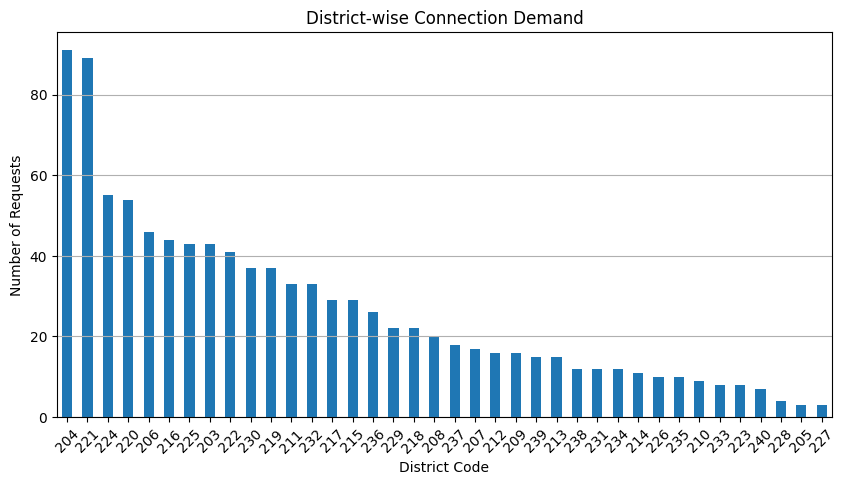

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ensure date is datetime
df["ENT_DATE"] = pd.to_datetime(df["ENT_DATE"])

# district-wise demand
district_demand = df.groupby("DIST_CODE")["REQ_NO"].count().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
district_demand.plot(kind="bar")
plt.title("District-wise Connection Demand")
plt.xlabel("District Code")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


Block-wise Connection Demand Graph (Top 10 Blocks)

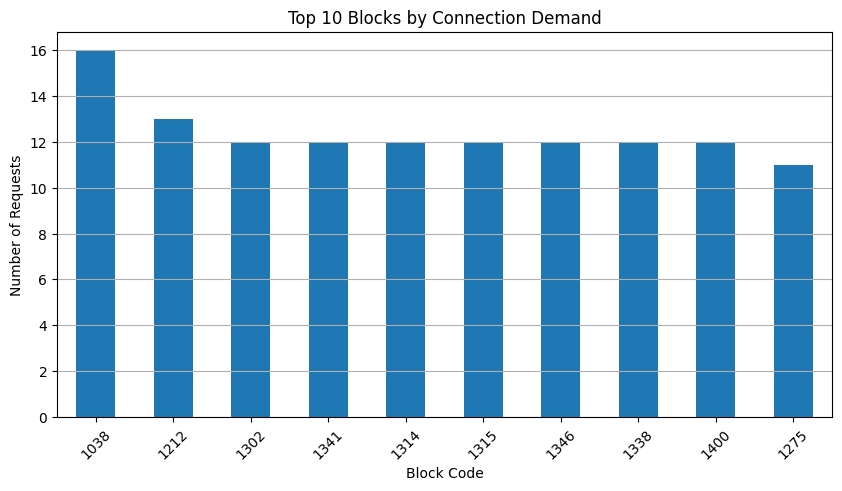

In [ ]:
# block-wise demand
block_demand = df.groupby("BLOCK_CODE")["REQ_NO"].count().sort_values(ascending=False)

# top 10 blocks
top_10_blocks = block_demand.head(10)

plt.figure(figsize=(10, 5))
top_10_blocks.plot(kind="bar")
plt.title("Top 10 Blocks by Connection Demand")
plt.xlabel("Block Code")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


District vs Block **Demand**

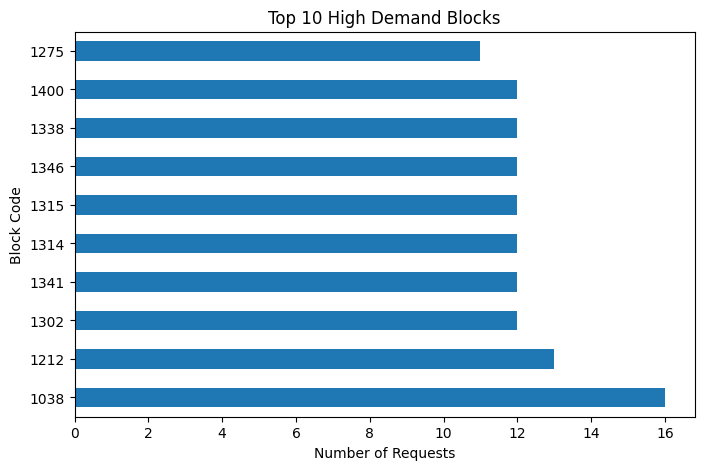

In [ ]:
top_10_blocks.plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 High Demand Blocks")
plt.xlabel("Number of Requests")
plt.ylabel("Block Code")
plt.show()


BAR CHART – OVERALL SERVICE TYPE **DEMAND**

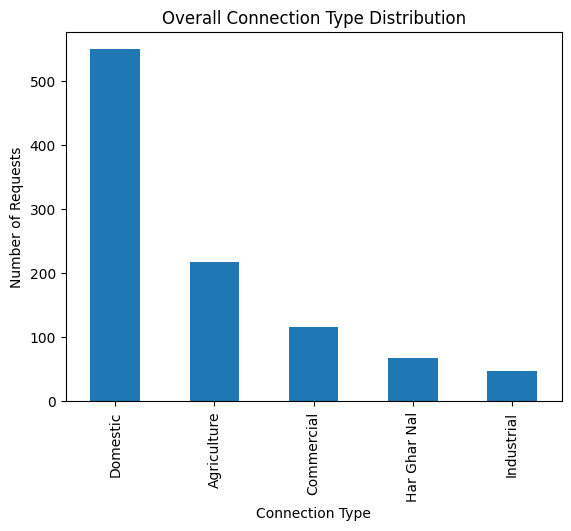

In [ ]:
df_model['CONN_TYPE'].value_counts().plot(kind='bar')
plt.title("Overall Connection Type Distribution")
plt.xlabel("Connection Type")
plt.ylabel("Number of Requests")
plt.show()


AREA-WISE ANALYSIS (DISTRICT LEVEL)

In [ ]:
district_ct = pd.crosstab(df_model['DIST_CODE'], df_model['CONN_TYPE'])
district_ct


CONN_TYPE,Agriculture,Commercial,Domestic,Har Ghar Nal,Industrial
DIST_CODE,,,,,
203,9,3,29,2,0
204,12,7,66,2,4
205,1,1,1,0,0
206,7,6,27,2,4
207,1,4,10,1,1
208,4,2,12,1,1
209,5,4,7,0,0
210,0,1,7,0,1
211,12,5,11,3,2


BAR CHART – DOMINANT SERVICE ACROSS DISTRICTS

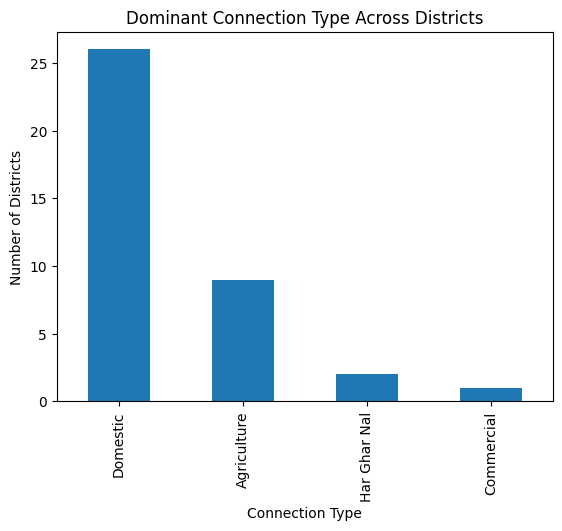

In [ ]:
district_ct['Most_Requested'] = district_ct.idxmax(axis=1)
district_ct['Most_Requested'].value_counts().plot(kind='bar')
plt.title("Dominant Connection Type Across Districts")
plt.xlabel("Connection Type")
plt.ylabel("Number of Districts")
plt.show()

HANDLE MISSING **VALUES**

In [ ]:
df.dropna(inplace=True)


In [ ]:
print("After missing value handling:", df_model.shape)


After missing value handling: (1000, 7)


ENCODE CATEGORICAL VARIABLE

(XGBoost cannot accept object/string data) Columns to Encode

TARIFF_ID ,APP_SOURCE, CONN_TYPE (target)


In [ ]:
label_encoders = {}

for col in ["TARIFF_ID", "APP_SOURCE", "CONN_TYPE"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le



DEFINE FEATURES & **TARGET**

In [ ]:
# FEATURES (Input variables)
X = df[
    [
        "DIST_CODE",
        "BLOCK_CODE",
        "TARIFF_ID",
        "SANC_LOAD",
        "APPPHASE",
        "APP_SOURCE"
    ]
]

# TARGET (Output variable)
y = df["CONN_TYPE"]


TRAIN-TEST **SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


HANDLE CLASS IMBALANCE (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)


TRAIN MULTI-CLASS XGBOOST **MODEL**

In [ ]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)
print("✅ XGBoost model training completed")


✅ XGBoost model training completed


MODEL **PREDICTION**

In [ ]:
y_pred = xgb_model.predict(X_test)


MODEL **ACCURACY**

In [ ]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))


Model Accuracy: 1.0


CONFUSION MATRIX (MODEL EVALUATION)

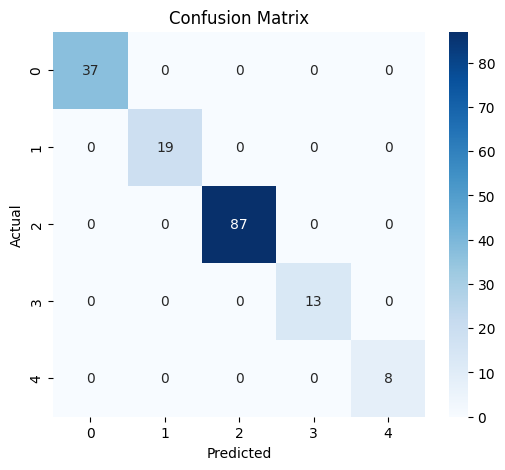

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        87
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8

    accuracy                           1.00       164
   macro avg       1.00      1.00      1.00       164
weighted avg       1.00      1.00      1.00       164



In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))


FUTURE PREDICTION (NEW AREA)

In [ ]:
new_area = pd.DataFrame({
    "DIST_CODE": [465],
    "BLOCK_CODE": [4657],
    "TARIFF_ID": [label_encoders["TARIFF_ID"].transform(["DS1D"])[0]],
    "SANC_LOAD": [3.0],
    "APPPHASE": [1],
    "APP_SOURCE": [label_encoders["APP_SOURCE"].transform(["MA"])[0]]
})

future_pred = xgb_model.predict(new_area)
future_type = label_encoders["CONN_TYPE"].inverse_transform(future_pred)

print("Predicted Connection Type:", future_type[0])


Predicted Connection Type: Domestic


FEATURE **IMPORTANCE**

In [ ]:
importance = xgb_model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, ":", round(score, 3))


DIST_CODE : 0.018
BLOCK_CODE : 0.014
TARIFF_ID : 0.652
SANC_LOAD : 0.223
APPPHASE : 0.083
APP_SOURCE : 0.011


FEATURE IMPORTANCE **GRAPH**

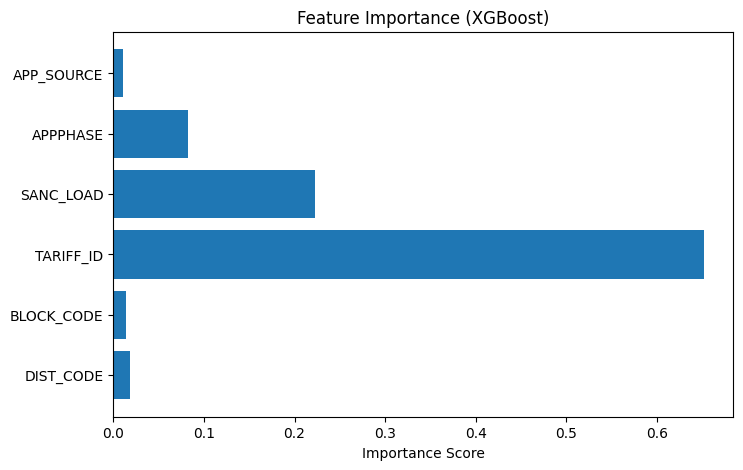

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.xlabel("Importance Score")
plt.title("Feature Importance (XGBoost)")
plt.show()


COMPARE MODELS (BEFORE vs AFTER)

In [ ]:
# Without SMOTE
xgb_no_smote = XGBClassifier(
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    random_state=42
)

xgb_no_smote.fit(X_train, y_train)
pred_no_smote = xgb_no_smote.predict(X_test)

print("Accuracy WITHOUT SMOTE:", accuracy_score(y_test, pred_no_smote))
print("Accuracy WITH SMOTE:", accuracy_score(y_test, y_pred))


Accuracy WITHOUT SMOTE: 1.0
Accuracy WITH SMOTE: 1.0


To predict future load demand **trend**

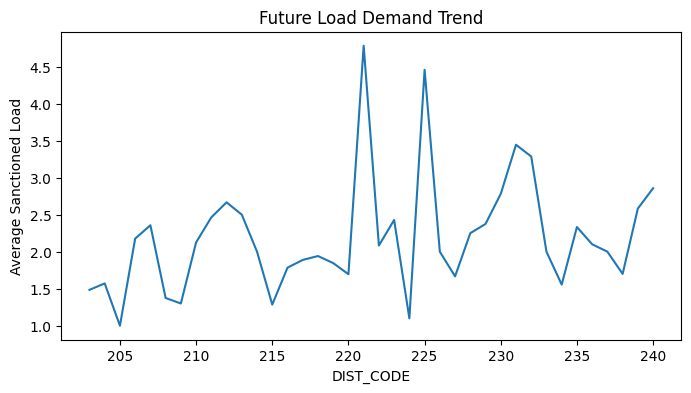

In [ ]:
load_trend = df.groupby("DIST_CODE")["SANC_LOAD"].mean()

load_trend.plot(kind="line", figsize=(8,4), title="Future Load Demand Trend")
plt.ylabel("Average Sanctioned Load")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


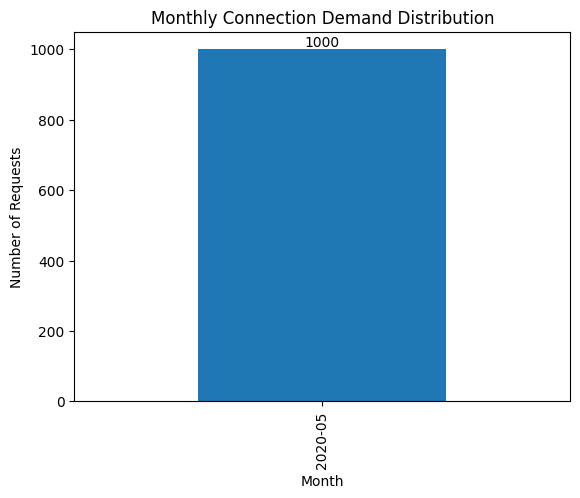

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load df (as it might not be defined if previous cells failed or weren't run)
df = pd.read_csv("/content/drive/MyDrive/NBPDCL/Copy of NSC_REQUEST.csv")

# Ensure 'ENT_DATE' is datetime and calculate monthly_demand
df["ENT_DATE"] = pd.to_datetime(df["ENT_DATE"])
monthly_demand = df.groupby(df["ENT_DATE"].dt.to_period("M"))["REQ_NO"].count()

monthly_demand.plot(kind="bar")
plt.title("Monthly Connection Demand Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Requests")

# add values on top of bars
for i, value in enumerate(monthly_demand):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

AREA-WISE DEMAND **HEATMAP**

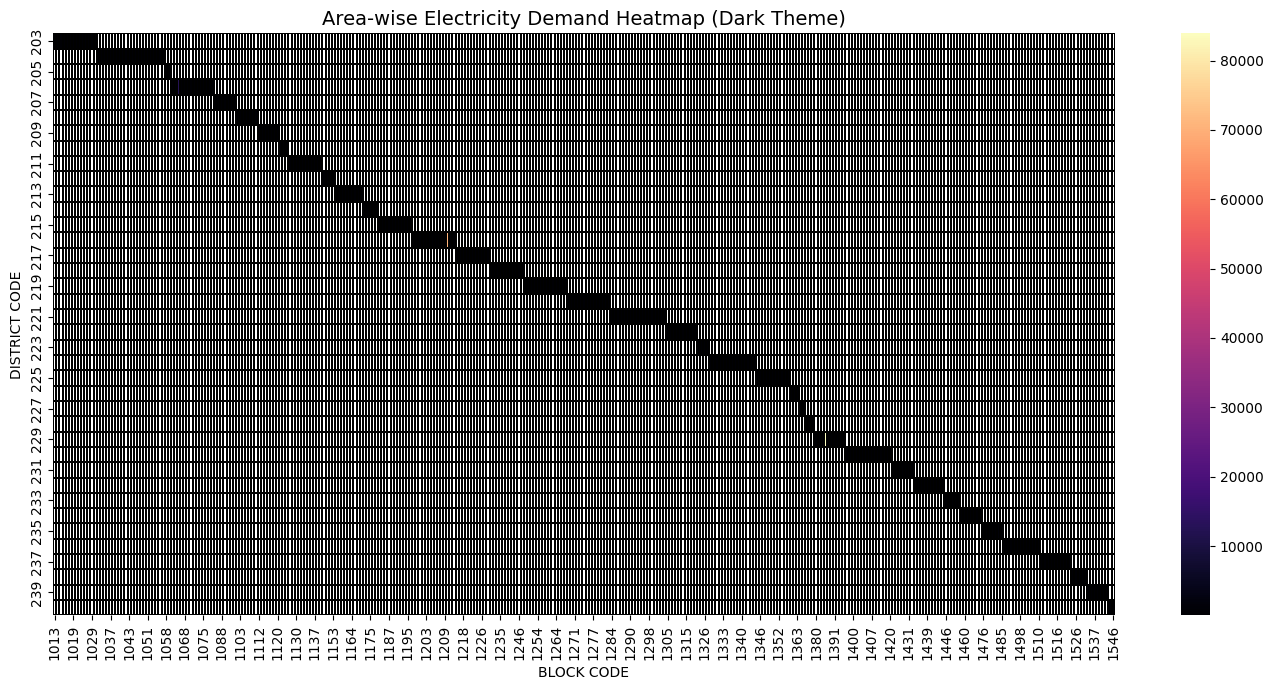

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table for area-wise demand
heatmap_data = df.pivot_table(
    values="SANC_LOAD",
    index="DIST_CODE",
    columns="BLOCK_CODE",
    aggfunc="mean"
)

# Plot heatmap with DARK color palette
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    cmap="magma",        # Dark color theme
    linewidths=0.3,
    linecolor="black"
)

plt.title("Area-wise Electricity Demand Heatmap (Dark Theme)", fontsize=14)
plt.xlabel("BLOCK CODE")
plt.ylabel("DISTRICT CODE")
plt.tight_layout()
plt.show()


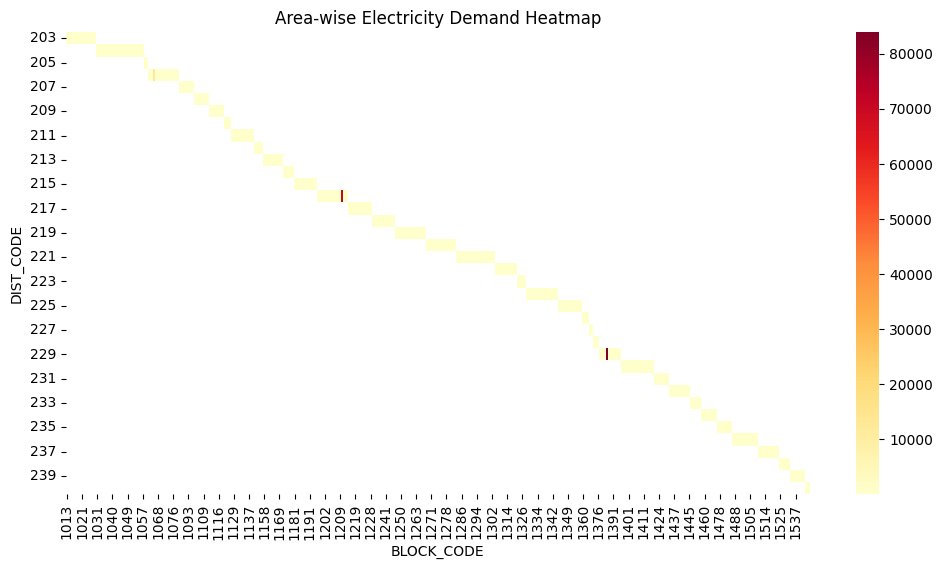

In [ ]:
heatmap_data = df.pivot_table(
    values="SANC_LOAD",
    index="DIST_CODE",
    columns="BLOCK_CODE",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Area-wise Electricity Demand Heatmap")
plt.show()


In [ ]:
import joblib
joblib.dump(xgb_model, "connection_type_xgb_model.joblib")
print("✅ XGBoost model saved successfully")
joblib.dump(label_encoders, "label_encoders.joblib")
print("✅ Label encoders saved successfully")
feature_names = X.columns.tolist()
joblib.dump(feature_names, "model_features.joblib")
print("✅ Feature list saved successfully")



✅ XGBoost model saved successfully
✅ Label encoders saved successfully
✅ Feature list saved successfully


In [ ]:
# Load saved files
model = joblib.load("connection_type_xgb_model.joblib")
encoders = joblib.load("label_encoders.joblib")
features = joblib.load("model_features.joblib")

print("✅ Model and files loaded successfully")


✅ Model and files loaded successfully


FUTURE PREDICTION USING SAVED **MODEL**

In [ ]:
new_data = pd.DataFrame({
    "DIST_CODE": [465],
    "BLOCK_CODE": [4657],
    "TARIFF_ID": [encoders["TARIFF_ID"].transform(["DS1D"])[0]],
    "SANC_LOAD": [3.0],
    "APPPHASE": [1],
    "APP_SOURCE": [encoders["APP_SOURCE"].transform(["MA"])[0]]
})

new_data = new_data[features]  # ensure correct order

prediction = model.predict(new_data)
result = encoders["CONN_TYPE"].inverse_transform(prediction)

print("Predicted Connection Type:", result[0])


Predicted Connection Type: Domestic
